# Basket Analysis (ML Model Application)

Goal: Identify commonly purchased product combinations and cross-sell opportunities.

In [2]:

import os, glob
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score


In [3]:
import os
import glob
import pandas as pd

DATA_DIR = "../data"

_TXN_RENAME = {
    "date": "purchase_date",
    "store_region": "store_r",
}

def find(pattern: str):
    hits = glob.glob(os.path.join(DATA_DIR, f"*{pattern}*"))
    if not hits:
        raise FileNotFoundError(f"No file matching {pattern}")
    return hits[0]

def clean_cols(df: pd.DataFrame, rename: dict = None):
    df.columns = (
        df.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
    )
    if rename:
        df = df.rename(columns=rename)
    return df

def load_data():
    transactions = clean_cols(
        pd.read_csv(find("transaction"), low_memory=False),
        _TXN_RENAME
    )

    products = clean_cols(
        pd.read_csv(find("product"), low_memory=False)
    )

    # SAFE MERGE (only if columns exist)
    if "commodity" not in transactions.columns:
        if {"product_num", "commodity"}.issubset(products.columns):
            transactions = transactions.merge(
                products[["product_num", "commodity"]],
                on="product_num",
                how="left"
            )

    return transactions, products

transactions, products = load_data()

print(transactions.columns)
transactions.head()

Index(['basket_num', 'hshd_num', 'purchase_', 'product_num', 'spend', 'units',
       'store_r', 'week_num', 'year', 'commodity'],
      dtype='str')


,basket_num,hshd_num,purchase_,product_num,spend,units,store_r,week_num,year,commodity
0,2,577,17-AUG-18,83652,0.59,1,CENTRAL,32,2018,MEDICATION
1,9,1916,17-AUG-18,6157725,3.49,1,WEST,32,2018,GROCERY STAPLE
2,16,514,17-AUG-18,654479,2.24,1,CENTRAL,32,2018,GROCERY STAPLE
3,16,514,17-AUG-18,8118,5.39,1,CENTRAL,32,2018,PRODUCE
4,25,361,17-AUG-18,94343,1.00,1,SOUTH,32,2018,PERSONAL CARE


In [4]:

def build_matrix(df):
    df = df[["hshd_num","commodity"]].dropna()
    df["commodity"] = df["commodity"].astype(str)

    mat = df.groupby(["hshd_num","commodity"]).size().unstack(fill_value=0)
    mat = mat.clip(upper=1)
    return mat

matrix = build_matrix(transactions)
matrix.head()


commodity,ACTIVITY,ALCOHOL,AUTO,BABY,BAKERY,BEVERAGE - NON WATER,BEVERAGE - WATER,BULK PRODUCTS,CANNED GOODS,CLOTHING,...,MISC,OUTDOOR,PERSONAL CARE,PET,PRODUCE,SEAFOOD,SEASONAL PRODUCTS,SPECIALTY FOOD,TOBACCO PRODUCTS,TOYS
hshd_num,,,,,,,,,,,,,,,,,,,,,
10,0,1,0,1,1,1,0,1,1,0,...,1,1,1,1,1,1,0,1,1,0
29,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,1,0,0,0,0,0
53,0,1,0,1,1,1,1,1,1,0,...,1,1,1,1,1,0,0,0,0,1
54,1,1,0,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0,1,0,0
60,0,1,1,1,1,1,1,1,1,1,...,1,1,1,1,1,1,0,1,1,1


In [5]:

def train_rf(matrix, top_n=25):
    results = []
    targets = matrix.sum().sort_values(ascending=False).head(top_n).index

    for t in targets:
        y = matrix[t].values
        X = matrix.drop(columns=[t]).values

        if y.sum() < 10:
            continue

        Xtr, Xte, ytr, yte = train_test_split(
            X, y, test_size=0.25, stratify=y, random_state=42
        )

        model = RandomForestClassifier(
            n_estimators=100,
            max_depth=6,
            class_weight="balanced",
            random_state=42
        )

        model.fit(Xtr, ytr)
        auc = roc_auc_score(yte, model.predict_proba(Xte)[:,1])

        importances = model.feature_importances_
        feats = matrix.drop(columns=[t]).columns

        top_feats = sorted(zip(feats, importances), key=lambda x: x[1], reverse=True)[:5]

        results.append({"target": t, "auc": round(auc,3), "top_cross_sells": top_feats})

    return results

results = train_rf(matrix)
results


[{'target': 'GROCERY STAPLE            ',
  'auc': 0.995,
  'top_cross_sells': [('IN STORE FOOD SERVICE     ',
    np.float64(0.15620097576708591)),
   ('CANNED GOODS              ', np.float64(0.12578669305573006)),
   ('MEAT - OTHER              ', np.float64(0.10382477848669576)),
   ('DELI                      ', np.float64(0.08088703402943107)),
   ('DAIRY                     ', np.float64(0.08039147977399126))]},
 {'target': 'PRODUCE                   ',
  'auc': 0.989,
  'top_cross_sells': [('CANNED GOODS              ',
    np.float64(0.15282425838488592)),
   ('DELI                      ', np.float64(0.14502945077929172)),
   ('MEAT - CHICKEN            ', np.float64(0.11015164170351138)),
   ('BAKERY                    ', np.float64(0.0729102620293381)),
   ('MEAT - PORK               ', np.float64(0.07032480318657106))]},
 {'target': 'BEVERAGE - NON WATER      ',
  'auc': 0.949,
  'top_cross_sells': [('DRY GOODS                 ',
    np.float64(0.14516446853914436)),
   ('M

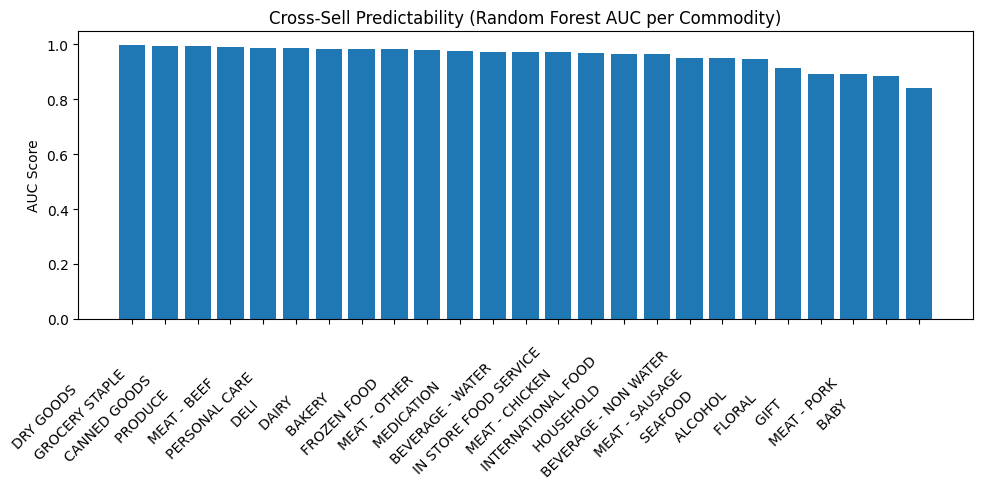

In [6]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert results into DataFrame
df = pd.DataFrame(results)

# Sort by AUC
df = df.sort_values("auc", ascending=False)

plt.figure(figsize=(10,5))
plt.bar(df["target"], df["auc"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("AUC Score")
plt.title("Cross-Sell Predictability (Random Forest AUC per Commodity)")
plt.tight_layout()
plt.show()

In [7]:
top_rows = df.head(5)

for _, row in top_rows.iterrows():
    print("\n==============================")
    print("TARGET:", row["target"])
    print("AUC:", row["auc"])
    print("Top Cross-Sell Signals:")

    for feat, score in row["top_cross_sells"]:
        print(f"  - {feat}: {round(score, 3)}")


TARGET: DRY GOODS                 
AUC: 0.997
Top Cross-Sell Signals:
  - MEAT - PORK               : 0.156
  - MEAT - BEEF               : 0.121
  - MEAT - OTHER              : 0.098
  - CANNED GOODS              : 0.089
  - INTERNATIONAL FOOD        : 0.085

TARGET: GROCERY STAPLE            
AUC: 0.995
Top Cross-Sell Signals:
  - IN STORE FOOD SERVICE     : 0.156
  - CANNED GOODS              : 0.126
  - MEAT - OTHER              : 0.104
  - DELI                      : 0.081
  - DAIRY                     : 0.08

TARGET: CANNED GOODS              
AUC: 0.993
Top Cross-Sell Signals:
  - MEAT - OTHER              : 0.143
  - MEAT - PORK               : 0.125
  - INTERNATIONAL FOOD        : 0.112
  - IN STORE FOOD SERVICE     : 0.106
  - DRY GOODS                 : 0.092

TARGET: PRODUCE                   
AUC: 0.989
Top Cross-Sell Signals:
  - CANNED GOODS              : 0.153
  - DELI                      : 0.145
  - MEAT - CHICKEN            : 0.11
  - BAKERY                    : 0.

In [8]:
from itertools import combinations
from collections import Counter

# Rebuild transaction-level item lists per household
basket_lists = (
    transactions[["hshd_num", "commodity"]]
    .dropna()
    .groupby("hshd_num")["commodity"]
    .apply(lambda x: list(set(x)))  # unique items per household
)

pair_counts = Counter()

for items in basket_lists:
    if len(items) < 2:
        continue
    for pair in combinations(sorted(items), 2):
        pair_counts[pair] += 1

top_5_pairs = pair_counts.most_common(5)

print("\nTop 5 Most Commonly Bought Together Item Pairs:\n")
for (item1, item2), count in top_5_pairs:
    print(f"{item1} + {item2}: {count}")


Top 5 Most Commonly Bought Together Item Pairs:

GROCERY STAPLE             + PRODUCE                   : 364
DAIRY                      + GROCERY STAPLE            : 361
BEVERAGE - NON WATER       + GROCERY STAPLE            : 358
DAIRY                      + PRODUCE                   : 356
FROZEN FOOD                + GROCERY STAPLE            : 355
